# Diabetes regression MLP: TinyMML vs Keras

Compare equivalent multilayer perceptron regressors implemented with TinyMML and Keras.


In [31]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

PROFILE_CONFIGS = {
    "reduced": {
        "train_samples": 250,
        "test_samples": 60,
        "epochs": 150,
        "batch_size": 32,
        "inference_repeats": 10,
    },
    "full": {
        "train_samples": 353,
        "test_samples": 89,
        "epochs": 1000,
        "batch_size": 32,
        "inference_repeats": 20,
    },
}

PROFILE = "full"  # Choose "reduced" or "full".
if PROFILE not in PROFILE_CONFIGS:
    raise ValueError("PROFILE must be 'reduced' or 'full'")

CONFIG = {
    **PROFILE_CONFIGS[PROFILE],
    "seed": 42,
    "learning_rate": 1e-2,
    "weight_decay": 1e-3,
}

In [32]:
from importlib.metadata import version
from pathlib import Path
from time import perf_counter
import platform
import sys

ROOT = Path.cwd()
if not (ROOT / "tinymodel").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display
from sklearn.datasets import load_diabetes
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
import keras

tf.config.set_visible_devices([], "GPU")

import tinytensor as tt
import tinymodel as tm

np.random.seed(CONFIG["seed"])
tt.manual_seed(CONFIG["seed"])
keras.utils.set_random_seed(CONFIG["seed"])
assert tf.config.get_visible_devices("GPU") == []

environment = {
    "profile": PROFILE,
    "platform": platform.platform(),
    "machine": platform.machine(),
    "logical CPUs": os.cpu_count(),
    "CPU threading": "runtime automatic",
    "Python": platform.python_version(),
    "NumPy": np.__version__,
    "TensorFlow": tf.__version__,
    "Keras": keras.__version__,
    "scikit-learn": version("scikit-learn"),
    "TinyTensor CUDA": tt.cuda_available(),
}

display(environment)
display(CONFIG)

{'profile': 'full',
 'platform': 'macOS-26.5.1-arm64-arm-64bit-Mach-O',
 'machine': 'arm64',
 'logical CPUs': 8,
 'CPU threading': 'runtime automatic',
 'Python': '3.13.14',
 'NumPy': '2.4.3',
 'TensorFlow': '2.21.0',
 'Keras': '3.15.0',
 'scikit-learn': '1.9.0',
 'TinyTensor CUDA': False}

{'train_samples': 353,
 'test_samples': 89,
 'epochs': 1000,
 'batch_size': 32,
 'inference_repeats': 20,
 'seed': 42,
 'learning_rate': 0.01,
 'weight_decay': 0.001}

## Dataset and experiment

The scikit-learn Diabetes dataset contains 442 patients, ten baseline clinical variables, and a continuous measure of disease progression one year later. The features cover age, sex, body-mass index, blood pressure, and six blood-serum measurements.

This notebook creates a reproducible train/test split, selects the requested profile, learns feature and target scaling from training data only, trains matched MLP regressors, then compares MAE, RMSE, R², timing, and residual behavior.


In [33]:
def subset_indices(length, count, seed):
    if count == length:
        return np.arange(length)
    return np.random.default_rng(seed).choice(
        length,
        size=count,
        replace=False,
    )


def benchmark_inference(predict, samples, repeats):
    predict()
    durations = []
    for _ in range(repeats):
        started = perf_counter()
        predict()
        durations.append(perf_counter() - started)

    median = float(np.median(durations))
    return 1_000 * median, samples / median


def markdown_table(rows, columns):
    header = "| " + " | ".join(columns) + " |"
    divider = "| " + " | ".join(["---"] * len(columns)) + " |"
    body = [
        "| " + " | ".join(str(row[column]) for column in columns) + " |"
        for row in rows
    ]
    return "\n".join([header, divider, *body])

## Load and select the data

The official dataset has no predefined train/test split, so this notebook reserves 20% for testing before selecting reduced or full profile rows.


In [34]:
dataset = load_diabetes()
x_all = dataset.data.astype(np.float32)
y_all = dataset.target.astype(np.float32)

x_pool_train, x_pool_test, y_pool_train, y_pool_test = train_test_split(
    x_all,
    y_all,
    test_size=0.2,
    random_state=CONFIG["seed"],
)
train_indices = subset_indices(
    len(x_pool_train),
    CONFIG["train_samples"],
    CONFIG["seed"],
)
test_indices = subset_indices(
    len(x_pool_test),
    CONFIG["test_samples"],
    CONFIG["seed"] + 1,
)
x_train = x_pool_train[train_indices]
y_train = y_pool_train[train_indices]
x_test = x_pool_test[test_indices]
y_test = y_pool_test[test_indices]

missing_values = int(np.isnan(x_all).sum() + np.isnan(y_all).sum())
print(f"Samples/features: {x_all.shape[0]} / {x_all.shape[1]}")
print(f"Selected train/test: {x_train.shape[0]} / {x_test.shape[0]}")
print(f"Missing values: {missing_values}")
print(
    "Target range and mean: "
    f"{y_all.min():.0f} to {y_all.max():.0f}; mean={y_all.mean():.1f}"
)

Samples/features: 442 / 10
Selected train/test: 353 / 89
Missing values: 0
Target range and mean: 25 to 346; mean=152.1


## Explore the dataset

Feature histograms show each baseline variable. The target histogram and correlation matrix summarize the regression problem before scaling.


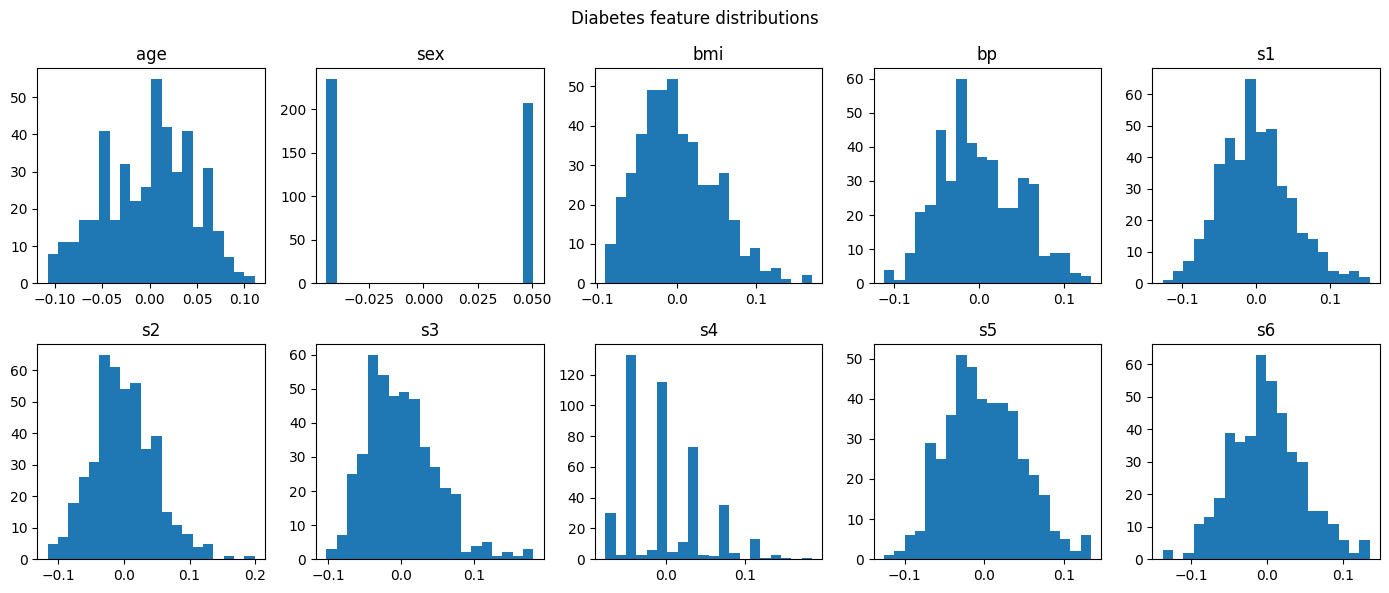

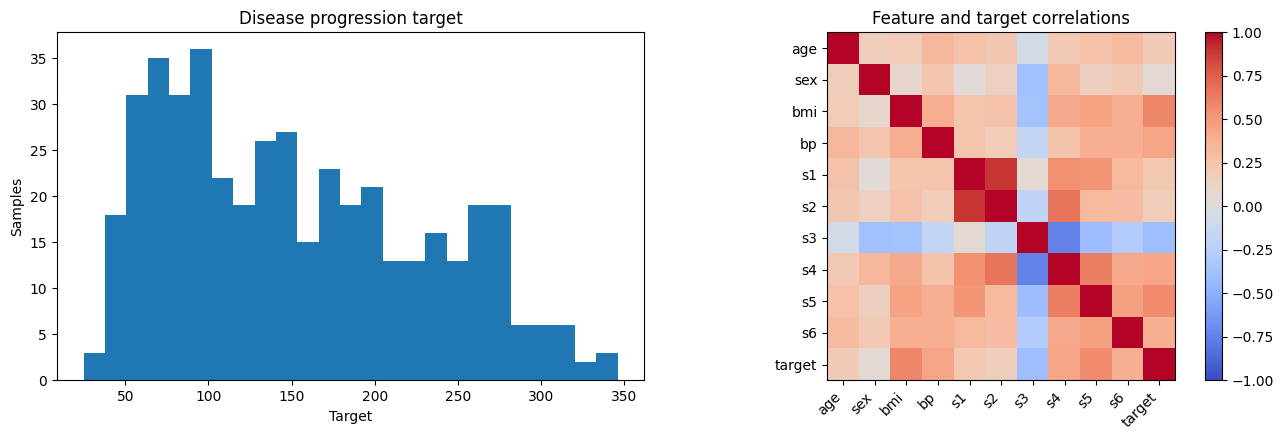

In [35]:
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for feature_index, axis in enumerate(axes.flat):
    axis.hist(x_all[:, feature_index], bins=20)
    axis.set_title(dataset.feature_names[feature_index])

plt.suptitle("Diabetes feature distributions")
plt.tight_layout()
plt.show()

correlations = np.corrcoef(
    np.column_stack([x_all, y_all]),
    rowvar=False,
)
labels = [*dataset.feature_names, "target"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(y_all, bins=25)
axes[0].set(
    title="Disease progression target",
    xlabel="Target",
    ylabel="Samples",
)

image = axes[1].imshow(correlations, cmap="coolwarm", vmin=-1, vmax=1)
axes[1].set_xticks(range(len(labels)), labels, rotation=45, ha="right")
axes[1].set_yticks(range(len(labels)), labels)
axes[1].set_title("Feature and target correlations")
fig.colorbar(image, ax=axes[1], fraction=0.046)

plt.tight_layout()
plt.show()

## Scale from training data only

Separate standardizers transform inputs and targets. Fitting them only on training rows prevents test information from leaking into model training.


In [36]:
x_scaler = StandardScaler()
y_scaler = StandardScaler()

x_train_scaled = x_scaler.fit_transform(x_train).astype(np.float32)
x_test_scaled = x_scaler.transform(x_test).astype(np.float32)
y_train_scaled = y_scaler.fit_transform(y_train[:, None]).astype(np.float32)

assert np.allclose(x_train_scaled.mean(axis=0), 0.0, atol=1e-5)
assert np.allclose(y_train_scaled.mean(), 0.0, atol=1e-5)

## Matched regression MLPs

Both models use `10 → 64 → ReLU → Dropout(0.1) → 32 → ReLU → 1`, He initialization, Adam at `1e-2` with `1e-3` weight decay, and mean squared error.


In [37]:
tiny_model = tm.Model([
    tm.Linear(64, init="he"),
    tm.ReLU(),
    tm.Dropout(0.1),
    tm.Linear(32, init="he"),
    tm.ReLU(),
    tm.Linear(1),
])
tiny_model.build(list(x_train_scaled.shape))
tiny_optimizer = tm.Adam(
    tiny_model.parameters(),
    lr=CONFIG["learning_rate"],
    weight_decay=CONFIG["weight_decay"],
)
tiny_loss = tm.MSELoss()

keras_model = keras.Sequential([
    keras.layers.Input(shape=(10,)),
    keras.layers.Dense(64, kernel_initializer="he_normal"),
    keras.layers.ReLU(),
    keras.layers.Dropout(0.1),
    keras.layers.Dense(32, kernel_initializer="he_normal"),
    keras.layers.ReLU(),
    keras.layers.Dense(1),
])
keras_model.compile(
    optimizer=keras.optimizers.Adam(
        CONFIG["learning_rate"],
        weight_decay=CONFIG["weight_decay"],
    ),
    loss="mse",
)

model_info = [
    {
        "library": "TinyMML",
        "parameters": sum(parameter.size() for parameter in tiny_model.parameters()),
        "steps/epoch": int(
            np.ceil(len(x_train_scaled) / CONFIG["batch_size"])
        ),
    },
    {
        "library": "Keras",
        "parameters": keras_model.count_params(),
        "steps/epoch": int(
            np.ceil(len(x_train_scaled) / CONFIG["batch_size"])
        ),
    },
]
display(Markdown(markdown_table(
    model_info,
    ["library", "parameters", "steps/epoch"],
)))

| library | parameters | steps/epoch |
| --- | --- | --- |
| TinyMML | 2817 | 12 |
| Keras | 2817 | 12 |

## Train and compare


Timings are CPU-only and hardware-dependent. Thread counts are left unset so OpenMP and TensorFlow can choose the available parallelism. Keras uses highly optimized TensorFlow kernels; TinyMML prioritizes a readable educational implementation, so equal runtime is not expected.


In [38]:
started = perf_counter()
tiny_history = tiny_model.fit(
    x_train_scaled,
    y_train_scaled,
    epochs=CONFIG["epochs"],
    batch_size=CONFIG["batch_size"],
    optimizer=tiny_optimizer,
    loss_fn=tiny_loss,
    verbose=False,
)
tiny_train_seconds = perf_counter() - started

started = perf_counter()
keras_history = keras_model.fit(
    x_train_scaled,
    y_train_scaled,
    epochs=CONFIG["epochs"],
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    verbose=0,
)
keras_train_seconds = perf_counter() - started

tiny_scaled_predictions = tiny_model.predict(
    x_test_scaled,
    batch_size=CONFIG["batch_size"],
)
keras_scaled_predictions = keras_model.predict(
    x_test_scaled,
    batch_size=CONFIG["batch_size"],
    verbose=0,
)
tiny_predictions = y_scaler.inverse_transform(
    tiny_scaled_predictions,
).reshape(-1)
keras_predictions = y_scaler.inverse_transform(
    keras_scaled_predictions,
).reshape(-1)

baseline_predictions = np.full_like(y_test, y_train.mean())
baseline_mae = mean_absolute_error(y_test, baseline_predictions)

tiny_latency, tiny_throughput = benchmark_inference(
    lambda: tiny_model.predict(
        x_test_scaled,
        batch_size=CONFIG["batch_size"],
    ),
    len(x_test_scaled),
    CONFIG["inference_repeats"],
)
keras_latency, keras_throughput = benchmark_inference(
    lambda: keras_model.predict(
        x_test_scaled,
        batch_size=CONFIG["batch_size"],
        verbose=0,
    ),
    len(x_test_scaled),
    CONFIG["inference_repeats"],
)


def result_row(library, predictions, training_seconds, latency, throughput):
    return {
        "library": library,
        "MAE": f"{mean_absolute_error(y_test, predictions):.2f}",
        "RMSE": f"{root_mean_squared_error(y_test, predictions):.2f}",
        "R2": f"{r2_score(y_test, predictions):.3f}",
        "training s": f"{training_seconds:.2f}",
        "inference ms": f"{latency:.3f}",
        "samples/s": f"{throughput:.1f}",
    }


results = [
    result_row(
        "TinyMML",
        tiny_predictions,
        tiny_train_seconds,
        tiny_latency,
        tiny_throughput,
    ),
    result_row(
        "Keras",
        keras_predictions,
        keras_train_seconds,
        keras_latency,
        keras_throughput,
    ),
]
display(Markdown(
    f"Train-mean MAE baseline: **{baseline_mae:.2f}**\n\n"
    + markdown_table(results, list(results[0]))
))

Train-mean MAE baseline: **64.01**

| library | MAE | RMSE | R2 | training s | inference ms | samples/s |
| --- | --- | --- | --- | --- | --- | --- |
| TinyMML | 45.61 | 60.95 | 0.299 | 10.75 | 0.433 | 205611.8 |
| Keras | 47.63 | 61.22 | 0.293 | 13.64 | 19.406 | 4586.1 |

## Diagnostics

Learning curves show optimization progress. Predicted-versus-actual values and residuals show regression quality beyond aggregate metrics.


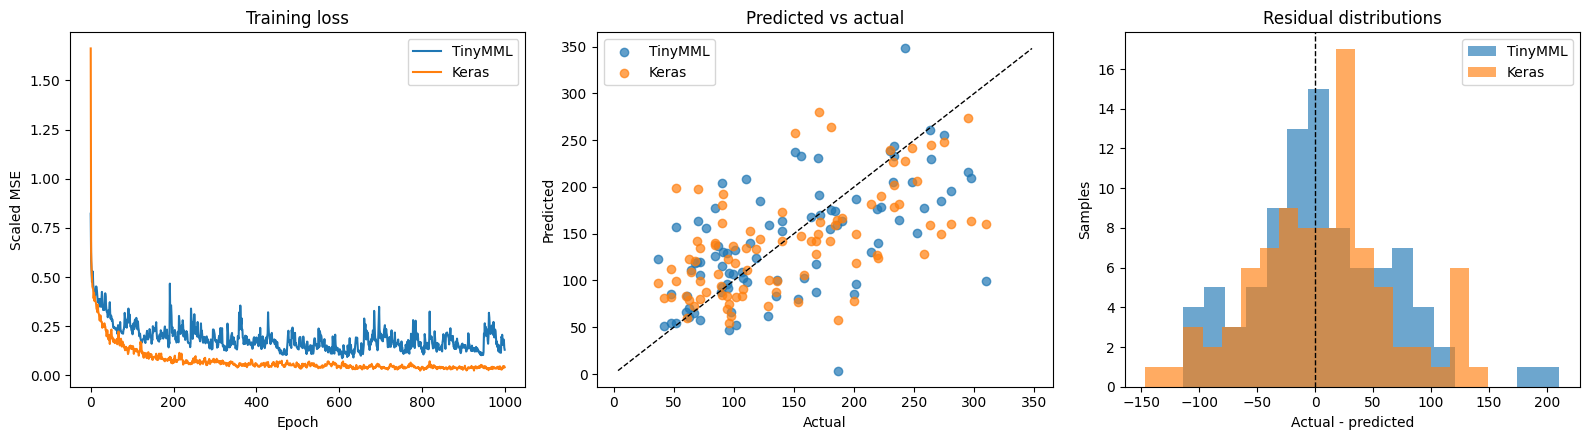

In [39]:
tiny_residuals = y_test - tiny_predictions
keras_residuals = y_test - keras_predictions

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].plot(tiny_history["loss"], label="TinyMML")
axes[0].plot(keras_history.history["loss"], label="Keras")
axes[0].set(
    title="Training loss",
    xlabel="Epoch",
    ylabel="Scaled MSE",
)
axes[0].legend()

limits = [
    min(y_test.min(), tiny_predictions.min(), keras_predictions.min()),
    max(y_test.max(), tiny_predictions.max(), keras_predictions.max()),
]
axes[1].scatter(y_test, tiny_predictions, alpha=0.7, label="TinyMML")
axes[1].scatter(y_test, keras_predictions, alpha=0.7, label="Keras")
axes[1].plot(limits, limits, "k--", linewidth=1)
axes[1].set(
    title="Predicted vs actual",
    xlabel="Actual",
    ylabel="Predicted",
)
axes[1].legend()

axes[2].hist(tiny_residuals, bins=18, alpha=0.65, label="TinyMML")
axes[2].hist(keras_residuals, bins=18, alpha=0.65, label="Keras")
axes[2].axvline(0, color="black", linestyle="--", linewidth=1)
axes[2].set(
    title="Residual distributions",
    xlabel="Actual - predicted",
    ylabel="Samples",
)
axes[2].legend()

plt.tight_layout()
plt.show()


In [40]:
combined_error = np.maximum(
    np.abs(tiny_residuals),
    np.abs(keras_residuals),
)
worst_indices = np.argsort(combined_error)[-8:][::-1]
worst_rows = [
    {
        "row": int(index),
        "actual": f"{y_test[index]:.1f}",
        "TinyMML": f"{tiny_predictions[index]:.1f}",
        "Keras": f"{keras_predictions[index]:.1f}",
        "max abs error": f"{combined_error[index]:.1f}",
    }
    for index in worst_indices
]
display(Markdown(
    "### Largest test-set prediction errors\n\n"
    + markdown_table(worst_rows, list(worst_rows[0]))
))

tiny_mae = mean_absolute_error(y_test, tiny_predictions)
keras_mae = mean_absolute_error(y_test, keras_predictions)
tiny_r2 = r2_score(y_test, tiny_predictions)
keras_r2 = r2_score(y_test, keras_predictions)

### Largest test-set prediction errors

| row | actual | TinyMML | Keras | max abs error |
| --- | --- | --- | --- | --- |
| 20 | 310.0 | 99.2 | 160.5 | 210.8 |
| 62 | 187.0 | 3.6 | 57.2 | 183.4 |
| 61 | 52.0 | 156.8 | 198.5 | 146.5 |
| 13 | 297.0 | 209.7 | 164.1 | 132.9 |
| 49 | 258.0 | 177.7 | 128.4 | 129.6 |
| 1 | 70.0 | 163.6 | 197.4 | 127.4 |
| 7 | 272.0 | 185.3 | 150.0 | 122.0 |
| 46 | 200.0 | 85.5 | 78.5 | 121.5 |